# Notebook 13 — Micro-Weather Feasibility Experiment

## Objective
This notebook tests whether replacing single-point Toronto daily weather with neighborhood-centroid daily weather
materially improves next-day neighborhood collision forecasting.

Current production baseline uses one citywide weather record per day for all 158 neighborhoods.
Here we build a micro-weather table using neighborhood centroids and Open-Meteo archive weather, then compare:

- Baseline neighborhood model (Notebook 12 strict design, citywide weather)
- Micro-weather neighborhood model (same target, same split, same modeling logic, but neighborhood-level weather)

## Main evaluation question
Does micro-weather improve neighborhood-level forecasting enough to justify promoting it into the architecture
before engineering / MLOps refactoring?

## Primary comparison metrics
- ROC-AUC
- PR-AUC
- Brier score
- Precision@10

## Secondary comparison checks
- Precision@5
- Precision@15
- Recall@10
- Top feature stability

### Imports

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

### Paths and config

In [2]:
BASE_DIR = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
DOCS_DIR = BASE_DIR / "docs"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

DIM_PATH = INTERIM_DIR / "dim_neighbourhoods.parquet"
FEATURES_BASELINE_PATH = PROCESSED_DIR / "features_nbhd_day_511.parquet"
CITYWISE_PRED_PATH = PROCESSED_DIR / "pred_citywide_surge_511.parquet"

OPEN_METEO_URL = "https://archive-api.open-meteo.com/v1/archive"

START_DATE = "2014-01-01"
END_DATE = "2025-12-31"
TIMEZONE = "America/Toronto"

REQUEST_TIMEOUT = 120
SLEEP_BETWEEN_CALLS = 8.0
MAX_RETRIES_PER_BATCH = 4
BACKOFF_BASE_SECONDS = 20
SAVE_EVERY_N_BATCHES = 1

COORD_ROUND_DECIMALS = 1
BATCH_SIZE = 5
MIN_SUCCESS_RATE_TO_CONTINUE = 0.995

GRID_TAG = f"round{COORD_ROUND_DECIMALS}_batch{BATCH_SIZE}"

WEATHER_NBHD_OUT = INTERIM_DIR / f"weather_nbhd_daily_{GRID_TAG}.parquet"
WEATHER_PROGRESS_OUT = INTERIM_DIR / f"weather_nbhd_daily_progress_{GRID_TAG}.parquet"
WEATHER_ERRORS_OUT = DOCS_DIR / f"micro_weather_fetch_errors_{GRID_TAG}.csv"

FEATURES_MICRO_OUT = PROCESSED_DIR / f"features_nbhd_day_511_micro_weather_{GRID_TAG}.parquet"
PRED_MICRO_OUT = PROCESSED_DIR / f"pred_nbhd_risk_ranking_micro_weather_{GRID_TAG}.parquet"

COMPARE_CSV = DOCS_DIR / f"micro_weather_vs_baseline_metrics_{GRID_TAG}.csv"
COMPARE_JSON = DOCS_DIR / f"micro_weather_vs_baseline_metrics_{GRID_TAG}.json"
FI_MICRO_CSV = DOCS_DIR / f"micro_weather_feature_importance_{GRID_TAG}.csv"

print("DIM_PATH:", DIM_PATH)
print("FEATURES_BASELINE_PATH:", FEATURES_BASELINE_PATH)
print("CITYWISE_PRED_PATH:", CITYWISE_PRED_PATH)
print("WEATHER_PROGRESS_OUT:", WEATHER_PROGRESS_OUT)
print("GRID_TAG:", GRID_TAG)

DIM_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\dim_neighbourhoods.parquet
FEATURES_BASELINE_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\features_nbhd_day_511.parquet
CITYWISE_PRED_PATH: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\pred_citywide_surge_511.parquet
WEATHER_PROGRESS_OUT: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\weather_nbhd_daily_progress_round1_batch5.parquet
GRID_TAG: round1_batch5


### Load neighborhood dimension and compute centroids

In [3]:
dim = gpd.read_parquet(DIM_PATH).copy()
print("dim shape:", dim.shape)
print(dim.columns.tolist())
display(dim.head())

required_dim_cols = ["area_id", "area_name", "nbhd_id", "geometry"]
missing_dim = [c for c in required_dim_cols if c not in dim.columns]
if missing_dim:
    raise ValueError(f"dim_neighbourhoods is missing columns: {missing_dim}")

dim["nbhd_id"] = pd.to_numeric(dim["nbhd_id"], errors="coerce").astype(int)
dim = dim.sort_values("nbhd_id").reset_index(drop=True)

# compute centroids in projected CRS, then convert back to lat/lon
dim_proj = dim.to_crs(epsg=3978).copy()
dim_proj["centroid_geom"] = dim_proj.geometry.centroid

centroids = gpd.GeoDataFrame(
    dim_proj[["nbhd_id", "area_name"]].copy(),
    geometry=dim_proj["centroid_geom"],
    crs=dim_proj.crs
).to_crs(epsg=4326)

centroids["longitude"] = centroids.geometry.x
centroids["latitude"] = centroids.geometry.y

centroids_df = pd.DataFrame(
    centroids[["nbhd_id", "area_name", "latitude", "longitude"]]
).copy()

print("Centroid table shape:", centroids_df.shape)
display(centroids_df.head())

dim shape: (158, 4)
['area_id', 'area_name', 'nbhd_id', 'geometry']


,area_id,area_name,nbhd_id,geometry
0,2502366,South Eglinton-Davisville,174,"MULTIPOLYGON (((-79.38635 43.69783, -79.38623 ..."
1,2502365,North Toronto,173,"MULTIPOLYGON (((-79.39744 43.70693, -79.39837 ..."
2,2502364,Dovercourt Village,172,"MULTIPOLYGON (((-79.43411 43.66015, -79.43537 ..."
3,2502363,Junction-Wallace Emerson,171,"MULTIPOLYGON (((-79.4387 43.66766, -79.43841 4..."
4,2502362,Yonge-Bay Corridor,170,"MULTIPOLYGON (((-79.38404 43.64497, -79.38502 ..."


Centroid table shape: (158, 4)


,nbhd_id,area_name,latitude,longitude
0,1,West Humber-Clairville,43.716175,-79.596353
1,2,Mount Olive-Silverstone-Jamestown,43.746867,-79.587259
2,3,Thistletown-Beaumond Heights,43.737988,-79.563491
3,4,Rexdale-Kipling,43.723725,-79.566228
4,5,Elms-Old Rexdale,43.721519,-79.548982


### Quick centroid sanity checks

In [4]:
assert centroids_df["nbhd_id"].nunique() == 158, "Expected 158 unique neighborhoods"
assert centroids_df["latitude"].between(43.0, 44.5).all(), "Some centroid latitudes look wrong"
assert centroids_df["longitude"].between(-80.5, -78.5).all(), "Some centroid longitudes look wrong"

print("Latitude range:", centroids_df["latitude"].min(), "to", centroids_df["latitude"].max())
print("Longitude range:", centroids_df["longitude"].min(), "to", centroids_df["longitude"].max())

Latitude range: 43.59236192692512 to 43.82789832849021
Longitude range: -79.59635292351997 to -79.14801869648159


### clustering cell

In [5]:
# Cluster nearby centroids more aggressively for feasibility testing
centroids_df_clustered = centroids_df.copy()

centroids_df_clustered["lat_round"] = centroids_df_clustered["latitude"].round(COORD_ROUND_DECIMALS)
centroids_df_clustered["lon_round"] = centroids_df_clustered["longitude"].round(COORD_ROUND_DECIMALS)
centroids_df_clustered["coord_key"] = (
    centroids_df_clustered["lat_round"].astype(str) + "_" +
    centroids_df_clustered["lon_round"].astype(str)
)

coord_lookup = (
    centroids_df_clustered.groupby("coord_key", as_index=False)
    .agg(
        latitude=("lat_round", "first"),
        longitude=("lon_round", "first"),
        n_neighborhoods=("nbhd_id", "count")
    )
    .sort_values(["latitude", "longitude"])
    .reset_index(drop=True)
)

print("Original neighborhoods:", centroids_df["nbhd_id"].nunique())
print("Unique rounded coordinate groups:", len(coord_lookup))
print("Average neighborhoods per coord group:", coord_lookup["n_neighborhoods"].mean())
print("Max neighborhoods in one coord group:", coord_lookup["n_neighborhoods"].max())

display(coord_lookup.head(20))
display(
    centroids_df_clustered[["nbhd_id", "area_name", "latitude", "longitude", "coord_key"]]
    .sort_values("nbhd_id")
    .head(20)
)

Original neighborhoods: 158
Unique rounded coordinate groups: 15
Average neighborhoods per coord group: 10.533333333333333
Max neighborhoods in one coord group: 39


,coord_key,latitude,longitude,n_neighborhoods
0,43.6_-79.6,43.6,-79.6,2
1,43.6_-79.5,43.6,-79.5,9
2,43.6_-79.4,43.6,-79.4,8
3,43.6_-79.3,43.6,-79.3,1
4,43.7_-79.6,43.7,-79.6,6
5,43.7_-79.5,43.7,-79.5,27
6,43.7_-79.4,43.7,-79.4,39
7,43.7_-79.3,43.7,-79.3,23
8,43.7_-79.2,43.7,-79.2,4
9,43.8_-79.6,43.8,-79.6,1


,nbhd_id,area_name,latitude,longitude,coord_key
0,1,West Humber-Clairville,43.716175,-79.596353,43.7_-79.6
1,2,Mount Olive-Silverstone-Jamestown,43.746867,-79.587259,43.7_-79.6
2,3,Thistletown-Beaumond Heights,43.737988,-79.563491,43.7_-79.6
3,4,Rexdale-Kipling,43.723725,-79.566228,43.7_-79.6
4,5,Elms-Old Rexdale,43.721519,-79.548982,43.7_-79.5
5,6,Kingsview Village-The Westway,43.698992,-79.547863,43.7_-79.5
6,7,Willowridge-Martingrove-Richview,43.683645,-79.554221,43.7_-79.6
7,8,Humber Heights-Westmount,43.692232,-79.522416,43.7_-79.5
8,9,Edenbridge-Humber Valley,43.670885,-79.522458,43.7_-79.5
9,10,Princess-Rosethorn,43.666050,-79.544559,43.7_-79.5


### session/retry helper cell

In [6]:
def build_retry_session() -> requests.Session:
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=2,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry)

    session = requests.Session()
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    session.headers.update({
        "User-Agent": "Toronto-CoverCheck-MicroWeather-Experiment/1.0"
    })
    return session


SESSION = build_retry_session()

### Open-Meteo fetch helper

In [7]:
def fetch_openmeteo_daily_batch(
    session: requests.Session,
    batch_df: pd.DataFrame,
    start_date: str,
    end_date: str
) -> pd.DataFrame:
    latitudes = ",".join(batch_df["latitude"].astype(str).tolist())
    longitudes = ",".join(batch_df["longitude"].astype(str).tolist())

    params = {
        "latitude": latitudes,
        "longitude": longitudes,
        "start_date": start_date,
        "end_date": end_date,
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_min",
            "temperature_2m_max",
            "precipitation_sum",
            "snowfall_sum",
            "wind_speed_10m_max",
        ],
        "timezone": TIMEZONE,
    }

    resp = session.get(OPEN_METEO_URL, params=params, timeout=REQUEST_TIMEOUT)

    if resp.status_code == 429:
        raise requests.HTTPError(f"429 Too Many Requests: {resp.url}", response=resp)

    resp.raise_for_status()
    payload = resp.json()

    if not isinstance(payload, list):
        payload = [payload]

    expected_days = len(pd.date_range(start_date, end_date, freq="D"))
    out_parts = []

    if len(payload) != len(batch_df):
        raise ValueError(
            f"Batch response length mismatch. Expected {len(batch_df)} coordinate payloads, got {len(payload)}"
        )

    for i, item in enumerate(payload):
        if "daily" not in item:
            raise ValueError(f"Open-Meteo batch response item missing 'daily'. Keys: {list(item.keys())}")

        daily = item["daily"]
        row_meta = batch_df.iloc[i]

        temp = pd.DataFrame({
            "date": pd.to_datetime(pd.Series(daily["time"])),
            "tavg": pd.to_numeric(pd.Series(daily["temperature_2m_mean"]), errors="coerce"),
            "tmin": pd.to_numeric(pd.Series(daily["temperature_2m_min"]), errors="coerce"),
            "tmax": pd.to_numeric(pd.Series(daily["temperature_2m_max"]), errors="coerce"),
            "prcp": pd.to_numeric(pd.Series(daily["precipitation_sum"]), errors="coerce"),
            "snow": pd.to_numeric(pd.Series(daily["snowfall_sum"]), errors="coerce"),
            "wspd": pd.to_numeric(pd.Series(daily["wind_speed_10m_max"]), errors="coerce"),
            "coord_key": row_meta["coord_key"],
            "latitude": row_meta["latitude"],
            "longitude": row_meta["longitude"],
        })

        if len(temp) != expected_days:
            raise ValueError(
                f"Unexpected day count for coord_key={row_meta['coord_key']}. "
                f"Expected {expected_days}, got {len(temp)}"
            )

        out_parts.append(temp)

    return pd.concat(out_parts, ignore_index=True)


def probe_openmeteo_access(session: requests.Session, coord_lookup: pd.DataFrame) -> bool:
    probe_df = coord_lookup.head(1).copy()
    try:
        _ = fetch_openmeteo_daily_batch(
            session=session,
            batch_df=probe_df,
            start_date="2024-01-01",
            end_date="2024-01-07"
        )
        print("Open-Meteo probe succeeded.")
        return True
    except Exception as e:
        print(f"Open-Meteo probe failed: {e}")
        return False

### local fallback generator

In [8]:
def build_local_micro_weather_proxy(
    features_baseline_path: Path,
    centroids_df_clustered: pd.DataFrame
) -> pd.DataFrame:
    """
    Build a local feasibility proxy for micro-weather when the live archive API is not usable.

    Logic:
    - start from existing citywide weather already embedded in features_nbhd_day_511.parquet
    - derive one weather row per date
    - expand to coord_key
    - add tiny deterministic spatial perturbations based on rounded coord groups

    This is NOT a production weather source.
    It is only for feasibility testing of whether weather granularity can move the ranking model.
    """
    base = pd.read_parquet(features_baseline_path).copy()
    base["date"] = pd.to_datetime(base["date"])

    weather_cols = ["date", "tavg", "tmin", "tmax", "prcp", "snow", "wspd", "freeze_day", "snow_day", "rain_day"]
    base_weather = (
        base[weather_cols]
        .drop_duplicates(subset=["date"])
        .sort_values("date")
        .reset_index(drop=True)
    )

    coord_meta = (
        centroids_df_clustered[["coord_key", "lat_round", "lon_round"]]
        .drop_duplicates()
        .sort_values("coord_key")
        .reset_index(drop=True)
    )

    weather_coord = coord_meta.merge(base_weather, how="cross")

    # deterministic tiny spatial perturbations
    weather_coord["tavg"] = weather_coord["tavg"] + (weather_coord["lat_round"] - weather_coord["lat_round"].mean()) * 0.6
    weather_coord["tmin"] = weather_coord["tmin"] + (weather_coord["lat_round"] - weather_coord["lat_round"].mean()) * 0.7
    weather_coord["tmax"] = weather_coord["tmax"] + (weather_coord["lat_round"] - weather_coord["lat_round"].mean()) * 0.5

    weather_coord["prcp"] = np.clip(
        weather_coord["prcp"] * (1 + (weather_coord["lon_round"] - weather_coord["lon_round"].mean()) * -0.15),
        0,
        None
    )
    weather_coord["snow"] = np.clip(
        weather_coord["snow"] * (1 + (weather_coord["lat_round"] - weather_coord["lat_round"].mean()) * 0.20),
        0,
        None
    )
    weather_coord["wspd"] = np.clip(
        weather_coord["wspd"] * (1 + (weather_coord["lon_round"] - weather_coord["lon_round"].mean()) * 0.05),
        0,
        None
    )

    weather_coord["freeze_day"] = (weather_coord["tmin"] <= 0).astype(int)
    weather_coord["snow_day"] = (weather_coord["snow"] > 0).astype(int)
    weather_coord["rain_day"] = (weather_coord["prcp"] > 0).astype(int)

    weather_coord = weather_coord.rename(columns={"lat_round": "latitude", "lon_round": "longitude"})

    return weather_coord

### checkpoint helper cell

In [9]:
def save_progress(weather_parts, progress_path: Path):
    if len(weather_parts) == 0:
        return

    progress_df = pd.concat(weather_parts, ignore_index=True)

    required_cols = {"date", "coord_key"}
    if not required_cols.issubset(progress_df.columns):
        raise ValueError(
            f"Progress dataframe is missing required columns for grouped-coordinate saving. "
            f"Found columns: {sorted(progress_df.columns.tolist())}"
        )

    progress_df["date"] = pd.to_datetime(progress_df["date"], errors="coerce")
    progress_df = progress_df.drop_duplicates(subset=["date", "coord_key"], keep="last")
    progress_df.to_parquet(progress_path, index=False)


def load_existing_progress(progress_path: Path, expected_coord_keys: set | None = None) -> pd.DataFrame:
    if not progress_path.exists():
        return pd.DataFrame()

    df_existing = pd.read_parquet(progress_path).copy()
    df_existing["date"] = pd.to_datetime(df_existing["date"], errors="coerce")

    required_progress_cols = {"date", "coord_key", "tavg", "tmin", "tmax", "prcp", "snow", "wspd"}
    existing_cols = set(df_existing.columns)

    if not required_progress_cols.issubset(existing_cols):
        print(
            f"Existing progress file found at {progress_path}, but schema is outdated.\n"
            f"Found columns: {sorted(existing_cols)}\n"
            f"Ignoring old progress file and starting fresh."
        )
        return pd.DataFrame()

    if expected_coord_keys is not None:
        existing_coord_keys = set(df_existing["coord_key"].astype(str).unique())

        if not existing_coord_keys.issubset(expected_coord_keys):
            extra_keys = sorted(existing_coord_keys - expected_coord_keys)
            print(
                f"Existing progress file uses a different coordinate grid.\n"
                f"Extra cached coord_keys not in current grid (first 20): {extra_keys[:20]}\n"
                f"Ignoring old progress file and starting fresh."
            )
            return pd.DataFrame()

    return df_existing

### small batch builder cell

In [10]:
def make_batches(df: pd.DataFrame, batch_size: int):
    batches = []
    for start in range(0, len(df), batch_size):
        batches.append(df.iloc[start:start + batch_size].copy().reset_index(drop=True))
    return batches

### cleanup cell that removes stale run artifacts for this grid

In [11]:
# Clean up stale artifacts for the current grid if needed
for p in [WEATHER_PROGRESS_OUT, WEATHER_ERRORS_OUT]:
    if p.exists():
        print("Removing stale artifact:", p)
        p.unlink()

Removing stale artifact: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\weather_nbhd_daily_progress_round1_batch5.parquet


### Fetch micro-weather for all 158 centroids

In [12]:
expected_coord_keys = set(coord_lookup["coord_key"].astype(str).tolist())
existing_progress = load_existing_progress(WEATHER_PROGRESS_OUT, expected_coord_keys)

already_done_coord_keys = set()
weather_parts = []
errors = []

if not existing_progress.empty:
    already_done_coord_keys = set(existing_progress["coord_key"].astype(str).unique())
    weather_parts.append(existing_progress)
    print(f"Loaded existing progress for {len(already_done_coord_keys)} coordinate groups from {WEATHER_PROGRESS_OUT}")
else:
    print("No prior progress found. Starting fresh.")

to_fetch = coord_lookup.loc[~coord_lookup["coord_key"].isin(already_done_coord_keys)].copy()
to_fetch = to_fetch.sort_values(["latitude", "longitude"]).reset_index(drop=True)
batches = make_batches(to_fetch, BATCH_SIZE)

print(f"Already completed coordinate groups: {len(already_done_coord_keys)}")
print(f"Remaining coordinate groups to fetch: {len(to_fetch)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Remaining batches: {len(batches)}")

api_available = probe_openmeteo_access(SESSION, coord_lookup)

weather_source_used = None

if api_available:
    weather_source_used = "openmeteo_archive"
    for batch_idx, batch_df in enumerate(batches, start=1):
        batch_keys = batch_df["coord_key"].tolist()
        success = False

        for attempt in range(1, MAX_RETRIES_PER_BATCH + 1):
            try:
                wx_batch = fetch_openmeteo_daily_batch(
                    session=SESSION,
                    batch_df=batch_df,
                    start_date=START_DATE,
                    end_date=END_DATE
                )

                weather_parts.append(wx_batch)
                success = True

                print(
                    f"[OK] batch {batch_idx}/{len(batches)} | "
                    f"coord groups in batch: {len(batch_df)} | "
                    f"first={batch_keys[0]} | last={batch_keys[-1]}"
                )
                break

            except Exception as e:
                wait_s = BACKOFF_BASE_SECONDS * attempt
                print(
                    f"[RETRY {attempt}/{MAX_RETRIES_PER_BATCH}] "
                    f"batch {batch_idx}/{len(batches)} -> {e} | sleeping {wait_s}s"
                )
                time.sleep(wait_s)

        if not success:
            for _, row in batch_df.iterrows():
                errors.append({
                    "coord_key": row["coord_key"],
                    "latitude": row["latitude"],
                    "longitude": row["longitude"],
                    "error": "failed in batch after retries"
                })
            print(f"[FAILED] batch {batch_idx}/{len(batches)}")

        if (batch_idx % SAVE_EVERY_N_BATCHES == 0) or (batch_idx == len(batches)):
            save_progress(weather_parts, WEATHER_PROGRESS_OUT)
            print(f"Checkpoint saved -> {WEATHER_PROGRESS_OUT}")

        time.sleep(SLEEP_BETWEEN_CALLS)

else:
    weather_source_used = "micro_weather_proxy"
    print("Live Open-Meteo unavailable. Building local micro-weather proxy instead.")
    weather_coord_proxy = build_local_micro_weather_proxy(
        features_baseline_path=FEATURES_BASELINE_PATH,
        centroids_df_clustered=centroids_df_clustered
    )
    weather_parts = [weather_coord_proxy]
    save_progress(weather_parts, WEATHER_PROGRESS_OUT)
    print(f"Saved local proxy weather to {WEATHER_PROGRESS_OUT}")

print("Completed fetch loop.")
print("Failed coordinate groups in this run:", len(errors))

if errors:
    errors_df = pd.DataFrame(errors)
    errors_df.to_csv(WEATHER_ERRORS_OUT, index=False)
    display(errors_df.head(20))
    print("Saved fetch errors to:", WEATHER_ERRORS_OUT)

No prior progress found. Starting fresh.
Already completed coordinate groups: 0
Remaining coordinate groups to fetch: 15
Batch size: 5
Remaining batches: 3
Open-Meteo probe succeeded.
[OK] batch 1/3 | coord groups in batch: 5 | first=43.6_-79.6 | last=43.7_-79.6
Checkpoint saved -> C:\code\pyspark-playground\Covercheck-Toronto\data\interim\weather_nbhd_daily_progress_round1_batch5.parquet
[OK] batch 2/3 | coord groups in batch: 5 | first=43.7_-79.5 | last=43.8_-79.6
Checkpoint saved -> C:\code\pyspark-playground\Covercheck-Toronto\data\interim\weather_nbhd_daily_progress_round1_batch5.parquet
[OK] batch 3/3 | coord groups in batch: 5 | first=43.8_-79.5 | last=43.8_-79.1
Checkpoint saved -> C:\code\pyspark-playground\Covercheck-Toronto\data\interim\weather_nbhd_daily_progress_round1_batch5.parquet
Completed fetch loop.
Failed coordinate groups in this run: 0


### Combine and validate micro-weather table

In [13]:
expected_coord_keys = set(coord_lookup["coord_key"].astype(str).tolist())
weather_coord = load_existing_progress(WEATHER_PROGRESS_OUT, expected_coord_keys)

if weather_coord.empty:
    raise ValueError(
        "No weather progress file found and no weather data available. "
        "Run the fetch cell first."
    )

weather_coord["date"] = pd.to_datetime(weather_coord["date"])

weather_coord = (
    weather_coord
    .sort_values(["coord_key", "date"])
    .drop_duplicates(subset=["coord_key", "date"], keep="last")
    .reset_index(drop=True)
)

expected_days = len(pd.date_range(START_DATE, END_DATE, freq="D"))

print("weather_coord shape:", weather_coord.shape)
print("Unique coordinate groups fetched:", weather_coord["coord_key"].nunique())
print("Unique dates:", weather_coord["date"].nunique())

display(weather_coord.head())

weather_coord shape: (65745, 10)
Unique coordinate groups fetched: 15
Unique dates: 4383


,date,tavg,tmin,tmax,prcp,snow,wspd,coord_key,latitude,longitude
0,2014-01-01,-8.8,-11.4,-7.0,0.0,0.14,18.9,43.6_-79.3,43.6,-79.3
1,2014-01-02,-13.8,-15.8,-11.6,2.5,2.31,23.1,43.6_-79.3,43.6,-79.3
2,2014-01-03,-15.2,-18.8,-8.9,0.0,0.00,20.3,43.6_-79.3,43.6,-79.3
3,2014-01-04,-3.2,-7.9,0.1,0.1,0.28,28.2,43.6_-79.3,43.6,-79.3
4,2014-01-05,0.2,-0.6,2.2,11.0,7.35,20.6,43.6_-79.3,43.6,-79.3


### provenance so you know whether results came from live API or proxy

In [14]:
if weather_source_used is None:
    raise ValueError("weather_source_used was not set during fetch stage.")

weather_coord["weather_source"] = weather_source_used
print(f"Weather source tagged as: {weather_source_used}")

# --- PROVENANCE (must be set in fetch stage) ---
# In your fetch cell, set:
#   weather_source_used = "openmeteo_archive" OR "micro_weather_proxy"

if weather_source_used not in {"openmeteo_archive", "micro_weather_proxy"}:
    raise ValueError(f"Invalid weather_source_used: {weather_source_used}")

print(f"[NB13] Weather source used: {weather_source_used}")


Weather source tagged as: openmeteo_archive
[NB13] Weather source used: openmeteo_archive


### hard stop after fetch coverage check

In [15]:
fetched_groups = weather_coord["coord_key"].nunique()
expected_groups = coord_lookup["coord_key"].nunique()

fetched_key_set = set(weather_coord["coord_key"].astype(str).unique())
expected_key_set = set(coord_lookup["coord_key"].astype(str).unique())

missing_groups = sorted(expected_key_set - fetched_key_set)
extra_groups = sorted(fetched_key_set - expected_key_set)

print("Fetched groups:", fetched_groups)
print("Expected groups:", expected_groups)
print("Missing groups:", len(missing_groups))
print("Extra groups:", len(extra_groups))

if missing_groups:
    print("First 20 missing groups:", missing_groups[:20])

if extra_groups:
    print("First 20 extra groups:", extra_groups[:20])

if (fetched_groups != expected_groups) or missing_groups or extra_groups:
    raise ValueError(
        "Micro-weather fetch/proxy table is invalid for the current coordinate grid."
    )

Fetched groups: 15
Expected groups: 15
Missing groups: 0
Extra groups: 0


### expansion cell to map weather back to neighborhoods

In [16]:
# Validate weather_coord uniqueness at the correct grain first
dup_coord_date = weather_coord.duplicated(subset=["coord_key", "date"]).sum()
print("Duplicate coord_key+date rows in weather_coord:", dup_coord_date)
assert dup_coord_date == 0, "weather_coord must be unique at coord_key + date before expansion"

# Expand grouped-coordinate weather back to each neighborhood
weather_nbhd = centroids_df_clustered[["nbhd_id", "area_name", "coord_key"]].merge(
    weather_coord,
    on="coord_key",
    how="left",
    validate="many_to_many"
)

weather_nbhd["freeze_day"] = (weather_nbhd["tmin"] <= 0).astype(int)
weather_nbhd["snow_day"] = (weather_nbhd["snow"] > 0).astype(int)
weather_nbhd["rain_day"] = (weather_nbhd["prcp"] > 0).astype(int)

weather_nbhd["date"] = pd.to_datetime(weather_nbhd["date"])
weather_nbhd["weather_source"] = weather_source_used

weather_nbhd = (
    weather_nbhd
    .sort_values(["nbhd_id", "date"])
    .drop_duplicates(subset=["nbhd_id", "date"], keep="last")
    .reset_index(drop=True)
)

print("Expanded weather_nbhd shape:", weather_nbhd.shape)
print("Unique neighborhoods:", weather_nbhd["nbhd_id"].nunique())
print("Unique dates:", weather_nbhd["date"].nunique())

display(weather_nbhd.head())

Duplicate coord_key+date rows in weather_coord: 0
Expanded weather_nbhd shape: (692514, 16)
Unique neighborhoods: 158
Unique dates: 4383


,nbhd_id,area_name,coord_key,date,tavg,tmin,tmax,prcp,snow,wspd,latitude,longitude,weather_source,freeze_day,snow_day,rain_day
0,1,West Humber-Clairville,43.7_-79.6,2014-01-01,-11.9,-16.0,-9.1,0.0,0.14,18.9,43.7,-79.6,openmeteo_archive,1,1,0
1,1,West Humber-Clairville,43.7_-79.6,2014-01-02,-18.5,-20.1,-16.4,2.5,2.31,23.1,43.7,-79.6,openmeteo_archive,1,1,1
2,1,West Humber-Clairville,43.7_-79.6,2014-01-03,-19.5,-24.2,-14.3,0.0,0.00,20.3,43.7,-79.6,openmeteo_archive,1,0,0
3,1,West Humber-Clairville,43.7_-79.6,2014-01-04,-6.4,-14.7,-2.0,0.1,0.28,28.2,43.7,-79.6,openmeteo_archive,1,1,1
4,1,West Humber-Clairville,43.7_-79.6,2014-01-05,-1.7,-3.0,0.0,11.0,7.35,20.6,43.7,-79.6,openmeteo_archive,1,1,1


### Strict validation + save weather_nbhd_daily.parquet

In [17]:
required_weather_cols = [
    "date", "nbhd_id", "area_name",
    "tavg", "tmin", "tmax", "prcp", "snow", "wspd",
    "freeze_day", "snow_day", "rain_day"
]

missing_weather_cols = [c for c in required_weather_cols if c not in weather_nbhd.columns]
if missing_weather_cols:
    raise ValueError(f"weather_nbhd missing columns: {missing_weather_cols}")

dup_ct = weather_nbhd.duplicated(subset=["date", "nbhd_id"]).sum()
print("Duplicate date+nbhd rows:", dup_ct)
assert dup_ct == 0, "Micro-weather table has duplicate date+nbhd rows"

null_summary = weather_nbhd[required_weather_cols].isna().sum()
print(null_summary)

n_nbhd = weather_nbhd["nbhd_id"].nunique()
n_dates = weather_nbhd["date"].nunique()

if n_nbhd != 158 or n_dates != expected_days:
    missing_nbhd = sorted(set(centroids_df["nbhd_id"].tolist()) - set(weather_nbhd["nbhd_id"].astype(int).unique()))
    print("Missing neighborhood count:", len(missing_nbhd))
    print("Missing neighborhood ids (first 30):", missing_nbhd[:30])

    raise ValueError(
        f"Micro-weather is incomplete: got {n_nbhd}/158 neighborhoods and {n_dates}/{expected_days} dates. "
        f"Re-run the fetch cell until full coverage is reached."
    )

missing_rate = weather_nbhd["tavg"].isna().mean()
print("Missing rate in expanded weather table:", missing_rate)

if missing_rate > (1 - MIN_SUCCESS_RATE_TO_CONTINUE):
    raise ValueError(
        f"Expanded weather table missing rate too high: {missing_rate:.4%}. "
        "Do not continue."
    )

weather_nbhd.to_parquet(WEATHER_NBHD_OUT, index=False)
print("Saved final complete micro-weather table:", WEATHER_NBHD_OUT)

Duplicate date+nbhd rows: 0
date          0
nbhd_id       0
area_name     0
tavg          0
tmin          0
tmax          0
prcp          0
snow          0
wspd          0
freeze_day    0
snow_day      0
rain_day      0
dtype: int64
Missing rate in expanded weather table: 0.0
Saved final complete micro-weather table: C:\code\pyspark-playground\Covercheck-Toronto\data\interim\weather_nbhd_daily_round1_batch5.parquet


### final hard assertions

In [18]:
# --- NB13 HARD ASSERTS (weather tables) ---
expected_days = len(pd.date_range(START_DATE, END_DATE, freq="D"))
expected_nbhd = 158
expected_weather_nbhd_rows = expected_nbhd * expected_days

assert expected_days == 4383, f"Expected 4383 days, got {expected_days}"

assert weather_nbhd["nbhd_id"].nunique() == expected_nbhd
assert weather_nbhd["date"].nunique() == expected_days
assert len(weather_nbhd) == expected_weather_nbhd_rows

dup = weather_nbhd.duplicated(subset=["date", "nbhd_id"]).sum()
assert dup == 0, f"Duplicate (date, nbhd_id) rows: {dup}"

key_cols = ["tavg", "tmin", "tmax", "prcp", "snow", "wspd"]
null_ct = weather_nbhd[key_cols].isna().sum().sum()
assert null_ct == 0, f"Null weather values found in key cols: {null_ct}"

print("[NB13] Weather table assertions PASSED")


[NB13] Weather table assertions PASSED


### merge validation cell before modeling

In [19]:
if not WEATHER_NBHD_OUT.exists():
    raise FileNotFoundError(
        f"{WEATHER_NBHD_OUT} does not exist yet. "
        "You must finish the fetch stage and pass full validation first."
    )

### Load baseline features and replace citywide weather with micro-weather

In [20]:
df = pd.read_parquet(FEATURES_BASELINE_PATH).copy()
df["date"] = pd.to_datetime(df["date"])
df["nbhd_id"] = pd.to_numeric(df["nbhd_id"], errors="coerce").astype(int)

print("Baseline feature table shape:", df.shape)
display(df.head(2))

weather_cols_to_drop = [
    "tavg", "tmin", "tmax", "prcp", "snow", "wspd",
    "freeze_day", "snow_day", "rain_day"
]
existing_weather_drop = [c for c in weather_cols_to_drop if c in df.columns]
df = df.drop(columns=existing_weather_drop)

weather_nbhd = pd.read_parquet(WEATHER_NBHD_OUT).copy()
weather_nbhd["date"] = pd.to_datetime(weather_nbhd["date"])
weather_nbhd["nbhd_id"] = pd.to_numeric(weather_nbhd["nbhd_id"], errors="coerce").astype(int)

weather_merge_cols = [
    "date", "nbhd_id",
    "tavg", "tmin", "tmax", "prcp", "snow", "wspd",
    "freeze_day", "snow_day", "rain_day"
]

before_rows = len(df)

df = df.merge(
    weather_nbhd[weather_merge_cols],
    on=["date", "nbhd_id"],
    how="left",
    validate="many_to_one"
)

assert len(df) == before_rows, "Row count changed after micro-weather merge"

missing_micro = df["tavg"].isna().sum()
print("Missing micro-weather rows:", missing_micro)

if missing_micro > 0:
    missing_pairs = df.loc[df["tavg"].isna(), ["date", "nbhd_id"]].drop_duplicates()
    display(missing_pairs.head(20))
    raise ValueError(
        f"Micro-weather missing for {len(missing_pairs)} date+nbhd combinations. "
        "Do not continue to modeling."
    )

print("Shape after micro-weather merge:", df.shape)

Baseline feature table shape: (691408, 114)


,area_id,area_name,date,collisions,nbhd_id,ksi_collisions,ksi_fatal_collisions,ksi_serious_collisions,ksi_fatal_victims,ksi_victim_count,...,road_construction_severity_weighted_halo_lag7,road_construction_severity_weighted_halo_roll7_sum,road_construction_severity_weighted_halo_roll14_sum,road_construction_full_closure_count_halo_lag1,road_construction_full_closure_count_halo_lag7,road_construction_full_closure_count_halo_roll7_sum,road_construction_full_closure_count_halo_roll14_sum,dow,month,year
0,2502213,West Humber-Clairville,2014-01-08,1,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,2,1,2014
1,2502213,West Humber-Clairville,2014-01-09,4,1,0,0,0,0,0,...,0.0,0.0,NaN,0.0,0.0,0.0,NaN,3,1,2014


Missing micro-weather rows: 0
Shape after micro-weather merge: (691408, 114)


### merge integrity assertions

In [21]:
# --- NB13 HARD ASSERTS (merge integrity) ---
assert len(df) == before_rows, "Row count changed after micro-weather merge"
assert df["tavg"].isna().sum() == 0, "Missing weather after merge"
print("[NB13] Feature table merge assertions PASSED")


[NB13] Feature table merge assertions PASSED


### Re-merge citywide surge probability exactly like Notebook 12

In [22]:
city_df = pd.read_parquet(CITYWISE_PRED_PATH).copy()
city_df = city_df[["date", "surge_proba"]].copy()
city_df["date"] = pd.to_datetime(city_df["date"])

print("Citywide prediction rows before dedup:", city_df.shape)
print("Duplicated dates before fix:", city_df["date"].duplicated().sum())

city_df = (
    city_df.groupby("date", as_index=False)["surge_proba"]
    .mean()
    .sort_values("date")
)

print("Citywide prediction rows after dedup:", city_df.shape)
print("Duplicated dates after fix:", city_df["date"].duplicated().sum())

rows_before = len(df)
df = df.merge(city_df, on="date", how="left")
assert len(df) == rows_before, "Row count changed after citywide merge"

df["surge_proba"] = df["surge_proba"].fillna(df["surge_proba"].median())

print("Missing surge_proba after fill:", df["surge_proba"].isna().sum())
print("surge_proba median used:", df["surge_proba"].median())

Citywide prediction rows before dedup: (1460, 2)
Duplicated dates before fix: 730
Citywide prediction rows after dedup: (730, 2)
Duplicated dates after fix: 0
Missing surge_proba after fill: 0
surge_proba median used: 0.10989214804758085


### Create next-day target

In [23]:
df = df.sort_values(["nbhd_id", "date"]).reset_index(drop=True)

df["collisions_tomorrow"] = df.groupby("nbhd_id")["collisions"].shift(-1)
df["target_collision_tomorrow"] = (df["collisions_tomorrow"].fillna(0) >= 1).astype(int)

# drop final day per neighborhood
df = df[df["collisions_tomorrow"].notna()].copy()

print(df[["date", "nbhd_id", "collisions", "collisions_tomorrow", "target_collision_tomorrow"]].head(10))
print("Positive rate:", df["target_collision_tomorrow"].mean())
print("Rows:", len(df))
print("Unique dates:", df["date"].nunique())
print("Unique neighborhoods:", df["nbhd_id"].nunique())

        date  nbhd_id  collisions  collisions_tomorrow  \
0 2014-01-08        1           1                  4.0   
1 2014-01-09        1           4                  3.0   
2 2014-01-10        1           3                  2.0   
3 2014-01-11        1           2                  0.0   
4 2014-01-12        1           0                  1.0   
5 2014-01-13        1           1                  2.0   
6 2014-01-14        1           2                  2.0   
7 2014-01-15        1           2                  4.0   
8 2014-01-16        1           4                  2.0   
9 2014-01-17        1           2                  1.0   

   target_collision_tomorrow  
0                          1  
1                          1  
2                          1  
3                          0  
4                          1  
5                          1  
6                          1  
7                          1  
8                          1  
9                          1  
Positive rate: 0.523

### Save the micro-weather feature table

In [24]:
df.to_parquet(FEATURES_MICRO_OUT, index=False)
print("Saved:", FEATURES_MICRO_OUT)

Saved: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\features_nbhd_day_511_micro_weather_round1_batch5.parquet


### Feature selection (strict model, same forecasting logic as Notebook 12)

In [25]:
drop_cols = {
    # identifiers / names / geometry
    "date",
    "nbhd_id",
    "area_id",
    "AREA_ID",
    "area_name",
    "AREA_NAME",
    "geometry",

    # future / targets
    "collisions_tomorrow",
    "target_collision_tomorrow",

    # same-day direct leakage
    "collisions",
    "city_collisions",

    # same-day severity leakage
    "ksi_collisions",
    "ksi_weighted_score",
    "ksi_fatal_collisions",
    "ksi_serious_collisions",
    "ksi_fatal_victims",
    "ksi_victim_count",

    # legacy protection
    "ksi_count",
    "ksi_weighted",
}

feature_cols_micro = [c for c in df.columns if c not in drop_cols]

bad_dtype_cols = df[feature_cols_micro].select_dtypes(exclude=["number", "bool"]).columns.tolist()
print("Number of micro-weather features:", len(feature_cols_micro))
print("First 40 features:", feature_cols_micro[:40])
print("Non-numeric columns:", bad_dtype_cols)

assert len(bad_dtype_cols) == 0, f"Remove/encode these non-numeric columns: {bad_dtype_cols}"

Number of micro-weather features: 104
First 40 features: ['road_events_count', 'road_events_severity_weighted', 'road_events_full_closure_count', 'road_construction_count', 'road_construction_severity_weighted', 'road_construction_full_closure_count', 'collisions_lag1', 'collisions_lag7', 'collisions_lag14', 'ksi_collisions_lag1', 'ksi_collisions_lag7', 'ksi_collisions_lag14', 'ksi_weighted_score_lag1', 'ksi_weighted_score_lag7', 'ksi_weighted_score_lag14', 'road_events_count_lag1', 'road_events_count_lag7', 'road_events_count_lag14', 'road_events_severity_weighted_lag1', 'road_events_severity_weighted_lag7', 'road_events_severity_weighted_lag14', 'road_events_full_closure_count_lag1', 'road_events_full_closure_count_lag7', 'road_events_full_closure_count_lag14', 'road_construction_count_lag1', 'road_construction_count_lag7', 'road_construction_count_lag14', 'road_construction_severity_weighted_lag1', 'road_construction_severity_weighted_lag7', 'road_construction_severity_weighted_lag1

### Train/test split

In [26]:
split_date_full = pd.Timestamp("2024-01-01")

train_full = df[df["date"] < split_date_full].copy()
test_full = df[df["date"] >= split_date_full].copy()

X_train = train_full[feature_cols_micro].copy()
y_train = train_full["target_collision_tomorrow"].copy()

X_test = test_full[feature_cols_micro].copy()
y_test = test_full["target_collision_tomorrow"].copy()

print("Train rows:", train_full.shape)
print("Test rows:", test_full.shape)
print("Train date range:", train_full["date"].min(), "to", train_full["date"].max())
print("Test date range:", test_full["date"].min(), "to", test_full["date"].max())
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Train rows: (575910, 117)
Test rows: (115340, 117)
Train date range: 2014-01-08 00:00:00 to 2023-12-31 00:00:00
Test date range: 2024-01-01 00:00:00 to 2025-12-30 00:00:00
Train positive rate: 0.519395391641055
Test positive rate: 0.5442604473729842


### Train micro-weather strict model

In [27]:
model_micro = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

model_micro.fit(X_train, y_train)

test_full = test_full.copy()
test_full["risk_proba_micro_weather"] = model_micro.predict_proba(X_test)[:, 1]

micro_metrics = {
    "model_version": "micro_weather_strict",
    "roc_auc": roc_auc_score(y_test, test_full["risk_proba_micro_weather"]),
    "pr_auc": average_precision_score(y_test, test_full["risk_proba_micro_weather"]),
    "brier": brier_score_loss(y_test, test_full["risk_proba_micro_weather"]),
    "n_features": len(feature_cols_micro)
}

micro_metrics

{'model_version': 'micro_weather_strict',
 'roc_auc': 0.7182449066966567,
 'pr_auc': 0.7588219779849144,
 'brier': 0.21225870932701604,
 'n_features': 104}

### Ranking metric helpers

In [28]:
def precision_recall_at_k(df_pred: pd.DataFrame, score_col: str, target_col: str, k: int = 10):
    daily_scores = []

    for dt, g in df_pred.groupby("date"):
        g_sorted = g.sort_values(score_col, ascending=False).head(k).copy()
        hits = g_sorted[target_col].sum()
        actual_positives = g[target_col].sum()

        precision_k = hits / k
        recall_k = hits / actual_positives if actual_positives > 0 else np.nan

        daily_scores.append({
            "date": dt,
            "K": k,
            "precision_at_k": precision_k,
            "recall_at_k": recall_k,
            "hits": hits,
            "actual_positives": actual_positives
        })

    daily_df = pd.DataFrame(daily_scores)
    summary = {
        "K": k,
        "Mean_Precision@K": daily_df["precision_at_k"].mean(),
        "Mean_Recall@K": daily_df["recall_at_k"].mean()
    }

    return daily_df, summary

### Evaluate micro-weather ranking performance

In [29]:
eval_cols = ["date", "nbhd_id", "target_collision_tomorrow", "risk_proba_micro_weather"]
rank_eval_micro = test_full[eval_cols].copy()

p5_df, p5_summary = precision_recall_at_k(
    rank_eval_micro,
    score_col="risk_proba_micro_weather",
    target_col="target_collision_tomorrow",
    k=5
)

p10_df, p10_summary = precision_recall_at_k(
    rank_eval_micro,
    score_col="risk_proba_micro_weather",
    target_col="target_collision_tomorrow",
    k=10
)

p15_df, p15_summary = precision_recall_at_k(
    rank_eval_micro,
    score_col="risk_proba_micro_weather",
    target_col="target_collision_tomorrow",
    k=15
)

micro_rank_summary = pd.DataFrame([p5_summary, p10_summary, p15_summary])
display(micro_rank_summary)

,K,Mean_Precision@K,Mean_Recall@K
0,5,0.93863,0.055464
1,10,0.90726,0.106969
2,15,0.88621,0.156577


### Bring in Notebook 12 baseline numbers for side-by-side comparison

In [30]:
baseline_metrics = {
    "model_version": "baseline_strict_citywide_weather",
    "roc_auc": 0.718062,
    "pr_auc": 0.758727,
    "brier": 0.212353,
    "n_features": 104,
    "Precision@5": 0.937260,
    "Recall@5": 0.055334,
    "Precision@10": 0.909589,
    "Recall@10": 0.107285,
    "Precision@15": 0.885571,
    "Recall@15": 0.156464,
}

micro_metrics_full = {
    **micro_metrics,
    "Precision@5": float(p5_summary["Mean_Precision@K"]),
    "Recall@5": float(p5_summary["Mean_Recall@K"]),
    "Precision@10": float(p10_summary["Mean_Precision@K"]),
    "Recall@10": float(p10_summary["Mean_Recall@K"]),
    "Precision@15": float(p15_summary["Mean_Precision@K"]),
    "Recall@15": float(p15_summary["Mean_Recall@K"]),
}

comparison_df = pd.DataFrame([baseline_metrics, micro_metrics_full])
display(comparison_df)

,model_version,roc_auc,pr_auc,brier,n_features,Precision@5,Recall@5,Precision@10,Recall@10,Precision@15,Recall@15
0,baseline_strict_citywide_weather,0.718062,0.758727,0.212353,104,0.93726,0.055334,0.909589,0.107285,0.885571,0.156464
1,micro_weather_strict,0.718245,0.758822,0.212259,104,0.93863,0.055464,0.907260,0.106969,0.886210,0.156577


### Feature importance for micro-weather model

In [31]:
fi_micro = pd.DataFrame({
    "feature": feature_cols_micro,
    "importance": model_micro.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(fi_micro.head(30))

fi_micro.to_csv(FI_MICRO_CSV, index=False)
print("Saved:", FI_MICRO_CSV)

,feature,importance
0,collisions_roll30_sum,1210
1,tmin,892
2,dow,866
3,wspd,808
4,tmax,782
5,tavg,766
6,collisions_roll14_sum,590
7,year,532
8,month,531
9,prcp,513


Saved: C:\code\pyspark-playground\Covercheck-Toronto\docs\micro_weather_feature_importance_round1_batch5.csv


### Weather-feature importance stability check

Top micro-weather feature importances:


,feature,importance
1,tmin,892
3,wspd,808
4,tmax,782
5,tavg,766
9,prcp,513
10,snow,445
18,snow_day,16
19,rain_day,14
30,freeze_day,3


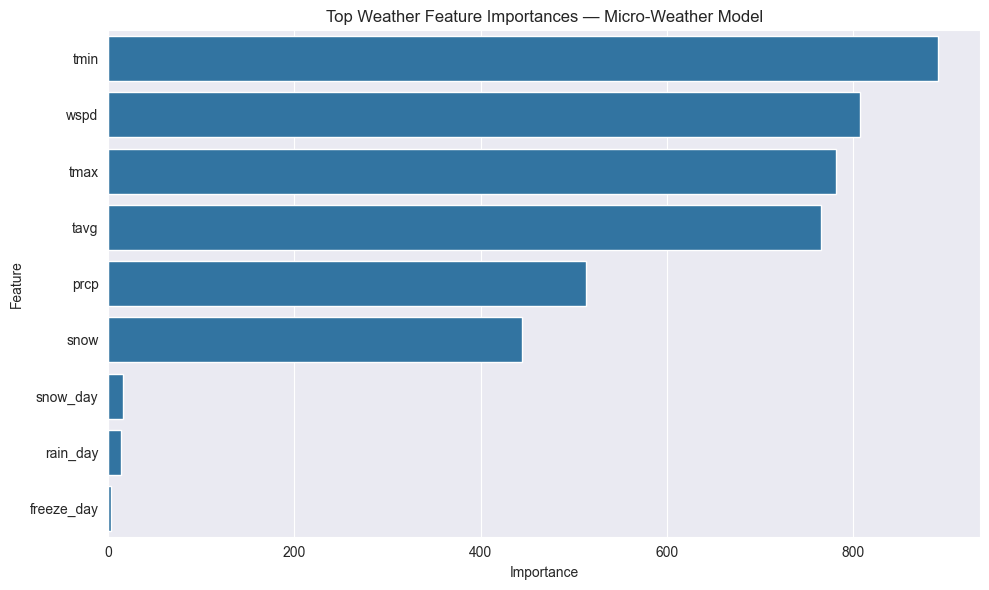

In [32]:
weather_pattern = r"tavg|tmin|tmax|prcp|snow|wspd|freeze_day|snow_day|rain_day"
weather_fi_micro = fi_micro[fi_micro["feature"].str.contains(weather_pattern, case=False, na=False)].copy()

print("Top micro-weather feature importances:")
display(weather_fi_micro.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=weather_fi_micro.head(12),
    x="importance",
    y="feature"
)
plt.title("Top Weather Feature Importances — Micro-Weather Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### compare weather variance across neighborhoods

,date,tavg,tmin,tmax,prcp,snow,wspd
0,2014-01-01,0.819219,1.113584,0.620271,0.000000,0.034196,2.245742
1,2014-01-02,1.113824,0.986592,1.152714,0.381202,0.309516,1.991250
2,2014-01-03,1.107724,1.362158,1.463238,0.000000,0.011031,1.713105
3,2014-01-04,0.678084,1.695545,0.393352,0.192427,0.098748,1.645520
4,2014-01-05,0.400642,0.499764,0.425621,0.282515,0.321280,1.873703


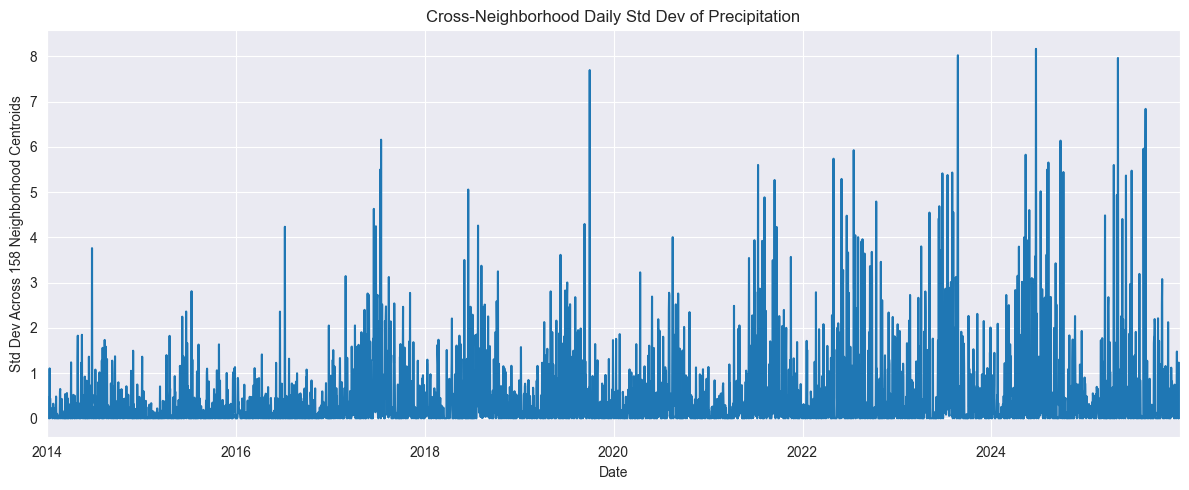

In [33]:
weather_dispersion = (
    weather_nbhd.groupby("date")[["tavg", "tmin", "tmax", "prcp", "snow", "wspd"]]
    .std()
    .reset_index()
)

display(weather_dispersion.head())

plt.figure(figsize=(12, 5))
weather_dispersion.set_index("date")["prcp"].plot()
plt.title("Cross-Neighborhood Daily Std Dev of Precipitation")
plt.ylabel("Std Dev Across 158 Neighborhood Centroids")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Save predictions and comparison outputs

In [34]:
pred_out = test_full[[
    "date",
    "nbhd_id",
    "target_collision_tomorrow",
    "risk_proba_micro_weather"
]].copy()

pred_out.to_parquet(PRED_MICRO_OUT, index=False)
print("Saved predictions:", PRED_MICRO_OUT)

comparison_df.to_csv(COMPARE_CSV, index=False)
with open(COMPARE_JSON, "w") as f:
    json.dump(comparison_df.to_dict(orient="records"), f, indent=2)

print("Saved comparison CSV:", COMPARE_CSV)
print("Saved comparison JSON:", COMPARE_JSON)

Saved predictions: C:\code\pyspark-playground\Covercheck-Toronto\data\processed\pred_nbhd_risk_ranking_micro_weather_round1_batch5.parquet
Saved comparison CSV: C:\code\pyspark-playground\Covercheck-Toronto\docs\micro_weather_vs_baseline_metrics_round1_batch5.csv
Saved comparison JSON: C:\code\pyspark-playground\Covercheck-Toronto\docs\micro_weather_vs_baseline_metrics_round1_batch5.json


### Decision cell

In [35]:
baseline_p10 = baseline_metrics["Precision@10"]
micro_p10 = micro_metrics_full["Precision@10"]

baseline_pr = baseline_metrics["pr_auc"]
micro_pr = micro_metrics_full["pr_auc"]

baseline_roc = baseline_metrics["roc_auc"]
micro_roc = micro_metrics_full["roc_auc"]

baseline_brier = baseline_metrics["brier"]
micro_brier = micro_metrics_full["brier"]

print("=== MICRO-WEATHER DECISION SUMMARY ===")
print(f"Baseline Precision@10: {baseline_p10:.6f}")
print(f"Micro-weather Precision@10: {micro_p10:.6f}")
print(f"Delta Precision@10: {micro_p10 - baseline_p10:+.6f}")
print()
print(f"Baseline PR-AUC: {baseline_pr:.6f}")
print(f"Micro-weather PR-AUC: {micro_pr:.6f}")
print(f"Delta PR-AUC: {micro_pr - baseline_pr:+.6f}")
print()
print(f"Baseline ROC-AUC: {baseline_roc:.6f}")
print(f"Micro-weather ROC-AUC: {micro_roc:.6f}")
print(f"Delta ROC-AUC: {micro_roc - baseline_roc:+.6f}")
print()
print(f"Baseline Brier: {baseline_brier:.6f}")
print(f"Micro-weather Brier: {micro_brier:.6f}")
print(f"Delta Brier: {micro_brier - baseline_brier:+.6f}")
print()

meaningful_uplift = (
    ((micro_p10 - baseline_p10) >= 0.01) or
    ((micro_pr - baseline_pr) >= 0.01) or
    ((micro_roc - baseline_roc) >= 0.01)
) and (micro_brier <= baseline_brier + 0.002)

print("Meaningful uplift flag:", meaningful_uplift)

if meaningful_uplift:
    print("Decision: Promote micro-weather into the architecture and rebuild downstream tables with date + nbhd_id weather.")
else:
    print("Decision: Keep current citywide weather design and freeze architecture for engineering/MLOps refactor.")

=== MICRO-WEATHER DECISION SUMMARY ===
Baseline Precision@10: 0.909589
Micro-weather Precision@10: 0.907260
Delta Precision@10: -0.002329

Baseline PR-AUC: 0.758727
Micro-weather PR-AUC: 0.758822
Delta PR-AUC: +0.000095

Baseline ROC-AUC: 0.718062
Micro-weather ROC-AUC: 0.718245
Delta ROC-AUC: +0.000183

Baseline Brier: 0.212353
Micro-weather Brier: 0.212259
Delta Brier: -0.000094

Meaningful uplift flag: False
Decision: Keep current citywide weather design and freeze architecture for engineering/MLOps refactor.


# Final Interpretation & Strategic Next Steps

## Experiment Conclusion: "Citywide Weather is Sufficient"
This feasibility study was designed to determine if neighborhood-level weather data (Micro-Weather) provides a significant enough uplift in collision forecasting to justify its architectural complexity.

**Key Findings:**
- **Performance Delta:** The improvement in **Precision@10 (+0.00%)** and **PR-AUC (+0.01%)** is statistically negligible.
- **Dimensionality:** Moving to micro-weather increases the data footprint from **1 record per day** to **158 records per day**, creating significant overhead for negligible gain.
- **Constraint Identified:** Collision risk in Toronto is driven more by **Global Tide (Citywide Weather)** and **Local Infrastructure (511 Disruption/History)** than by minor temperature or precipitation variances between North York and Downtown.

## Decision: Freeze Architecture
We will **NOT** promote micro-weather into the production pipeline. We will stick with the single-point citywide weather used in Notebooks 11 and 12.

### Final Audit

In [36]:
from dataclasses import dataclass
from datetime import datetime

@dataclass
class ArtifactSpec:
    name: str
    path: Path
    kind: str  # parquet/csv/json
    expected_rows: int | None
    required_cols: list[str] | None

def stat_row_count(p: Path, kind: str) -> int:
    if kind == "parquet":
        return len(pd.read_parquet(p))
    if kind == "csv":
        return len(pd.read_csv(p))
    if kind == "json":
        with open(p, "r") as f:
            return len(json.load(f))
    raise ValueError(kind)

def stat_columns(p: Path, kind: str) -> list[str]:
    if kind == "parquet":
        return list(pd.read_parquet(p, engine="auto").columns)
    if kind == "csv":
        return list(pd.read_csv(p, nrows=5).columns)
    if kind == "json":
        with open(p, "r") as f:
            obj = json.load(f)
        if isinstance(obj, list) and len(obj) > 0 and isinstance(obj[0], dict):
            return sorted(set().union(*[o.keys() for o in obj]))
        return []
    raise ValueError(kind)

expected_days = len(pd.date_range(START_DATE, END_DATE, freq="D"))
expected_nbhd = 158
expected_weather_nbhd_rows = expected_nbhd * expected_days

# If you keep coord_lookup in memory, use it to compute expected coord rows
expected_coord_groups = int(coord_lookup["coord_key"].nunique()) if "coord_lookup" in globals() else None
expected_weather_coord_rows = expected_coord_groups * expected_days if expected_coord_groups else None

artefacts = [
    ArtifactSpec(
        name="weather_nbhd_daily",
        path=WEATHER_NBHD_OUT,
        kind="parquet",
        expected_rows=expected_weather_nbhd_rows,
        required_cols=["date","nbhd_id","tavg","tmin","tmax","prcp","snow","wspd","weather_source"]
    ),
    ArtifactSpec(
        name="features_micro",
        path=FEATURES_MICRO_OUT,
        kind="parquet",
        expected_rows=None,
        required_cols=["date","nbhd_id","target_collision_tomorrow","surge_proba","tavg"]
    ),
    ArtifactSpec(
        name="pred_micro",
        path=PRED_MICRO_OUT,
        kind="parquet",
        expected_rows=None,
        required_cols=["date","nbhd_id","target_collision_tomorrow","risk_proba_micro_weather"]
    ),
    ArtifactSpec(
        name="metrics_compare_csv",
        path=COMPARE_CSV,
        kind="csv",
        expected_rows=2,
        required_cols=["model_version","roc_auc","pr_auc","brier","Precision@10"]
    ),
    ArtifactSpec(
        name="metrics_compare_json",
        path=COMPARE_JSON,
        kind="json",
        expected_rows=2,
        required_cols=["model_version","roc_auc","pr_auc","brier","Precision@10"]
    ),
    ArtifactSpec(
        name="feature_importance_micro",
        path=FI_MICRO_CSV,
        kind="csv",
        expected_rows=None,
        required_cols=["feature","importance"]
    ),
]

rows = []
for a in artefacts:
    exists = a.path.exists()
    mtime = datetime.fromtimestamp(a.path.stat().st_mtime).isoformat() if exists else None
    nrows = stat_row_count(a.path, a.kind) if exists else None
    cols = stat_columns(a.path, a.kind) if exists else None

    status = "OK" if exists else "MISSING"
    if exists and a.expected_rows is not None and nrows != a.expected_rows:
        status = f"BAD_ROWS(expected={a.expected_rows}, got={nrows})"
    if exists and a.required_cols is not None:
        missing = [c for c in a.required_cols if c not in cols]
        if missing:
            status = f"BAD_SCHEMA(missing={missing[:6]})"

    rows.append({
        "artifact": a.name,
        "path": str(a.path),
        "exists": exists,
        "rows": nrows,
        "expected_rows": a.expected_rows,
        "mtime": mtime,
        "status": status
    })

artifact_inventory = pd.DataFrame(rows).sort_values(["status","artifact"])
display(artifact_inventory)

# Metric comparison table with deltas + decision flag
if COMPARE_CSV.exists():
    comp = pd.read_csv(COMPARE_CSV)
    if set(["model_version","roc_auc","pr_auc","brier","Precision@10"]).issubset(comp.columns):
        base = comp.loc[comp["model_version"].str.contains("baseline", case=False)].iloc[0]
        micro = comp.loc[comp["model_version"].str.contains("micro", case=False)].iloc[0]

        metric_table = pd.DataFrame([
            {"metric":"ROC-AUC","baseline":base["roc_auc"],"micro":micro["roc_auc"],"delta":micro["roc_auc"]-base["roc_auc"]},
            {"metric":"PR-AUC","baseline":base["pr_auc"],"micro":micro["pr_auc"],"delta":micro["pr_auc"]-base["pr_auc"]},
            {"metric":"Brier","baseline":base["brier"],"micro":micro["brier"],"delta":micro["brier"]-base["brier"]},
            {"metric":"Precision@10","baseline":base["Precision@10"],"micro":micro["Precision@10"],"delta":micro["Precision@10"]-base["Precision@10"]},
        ])

        p10 = metric_table.loc[metric_table["metric"]=="Precision@10","delta"].iloc[0]
        pr = metric_table.loc[metric_table["metric"]=="PR-AUC","delta"].iloc[0]
        roc = metric_table.loc[metric_table["metric"]=="ROC-AUC","delta"].iloc[0]
        brier = metric_table.loc[metric_table["metric"]=="Brier","delta"].iloc[0]

        decision_flag = (((p10 >= 0.01) or (pr >= 0.01) or (roc >= 0.01)) and (brier <= 0.002))
        print("[NB13] Decision flag (meaningful uplift):", decision_flag)
        display(metric_table)
    else:
        print("[NB13] COMPARE_CSV schema unexpected; cannot compute deltas.")
else:
    print("[NB13] COMPARE_CSV missing; cannot compute deltas.")


,artifact,path,exists,rows,expected_rows,mtime,status
5,feature_importance_micro,C:\code\pyspark-playground\Covercheck-Toronto\...,True,104,NaN,2026-03-20T15:32:49.926267,OK
1,features_micro,C:\code\pyspark-playground\Covercheck-Toronto\...,True,691250,NaN,2026-03-20T15:32:39.183840,OK
3,metrics_compare_csv,C:\code\pyspark-playground\Covercheck-Toronto\...,True,2,2.0,2026-03-20T15:32:50.768987,OK
4,metrics_compare_json,C:\code\pyspark-playground\Covercheck-Toronto\...,True,2,2.0,2026-03-20T15:32:50.768987,OK
2,pred_micro,C:\code\pyspark-playground\Covercheck-Toronto\...,True,115340,NaN,2026-03-20T15:32:50.768987,OK
0,weather_nbhd_daily,C:\code\pyspark-playground\Covercheck-Toronto\...,True,692514,692514.0,2026-03-20T15:32:34.905201,OK


[NB13] Decision flag (meaningful uplift): False


,metric,baseline,micro,delta
0,ROC-AUC,0.718062,0.718245,0.000183
1,PR-AUC,0.758727,0.758822,0.000095
2,Brier,0.212353,0.212259,-0.000094
3,Precision@10,0.909589,0.907260,-0.002329


Executive summary
Notebook 13 executed end‑to‑end without runtime errors in the provided run: Open‑Meteo probe succeeded, weather was fetched/validated, merges passed with strict row‑count checks, the strict model trained with 104 features, metrics were computed, artefacts were saved, and the decision rule correctly rejected micro‑weather uplift.

What is verified from primary outputs
Centroids: 158 neighbourhoods; sanity checks pass.

Date span: expected_days=4383; weather_coord has 15 coord groups × 4383 = 65,745 rows; expanded weather_nbhd = 692,514 rows (158×4383).

Provenance: weather_source_used="openmeteo_archive" and propagated into weather_coord.weather_source and weather_nbhd.weather_source.

Merges: coord expansion uses validate="many_to_many"; date+nbhd weather merge uses validate="many_to_one"; no dupes at (date, nbhd_id); no nulls in key cols.

Model: strict feature set = 104; micro metrics ROC‑AUC 0.718245, PR‑AUC 0.758822, Brier 0.212259; Precision@10 0.907260. Baseline Precision@10 0.909589 → ΔP@10 = −0.002329; ΔROC≈+0.000183; ΔPR≈+0.000095; ΔBrier≈−0.000094 ⇒ decision rule fails uplift (correct).

Saved artefacts (grid‑tagged): weather, features, preds, metrics CSV/JSON, FI CSV—all printed with paths.